# 🇮🇹 Italian Industrial Production

**Source:** [ISTAT](https://www.istat.it/) — Istituto Nazionale di Statistica  
**TidyTuesday:** Week 18, 2026 | Curated by [Nicola Rennie](https://github.com/nrennie)

---

ISTAT publishes long-running time series on Italian industrial production covering over 100 years (1861–1985), originally compiled in the *Sommari di statistiche storiche* (Historical Statistics Summaries). The data spans food & beverages, textiles, and transport equipment.

This notebook focuses on **food & beverages** — tracing sugar, beer, seed oil, alcohol and more across some of Italy's most turbulent historical periods: the Industrial Revolution, two World Wars, Fascist autarchy, and the postwar economic miracle.

**Key questions:**
- Which products grew or collapsed over time — and when?
- How do wartime periods show up in production data?
- Does Fascist autarchy (1922–1939) leave a visible fingerprint on domestic food production?

> ⚠️ *Note: figures for 1871–1950 refer to the fiscal year, not the calendar year. From 1951 onward, figures are calendar year. 1943 has no data — Italy's government collapsed mid-year during WWII.*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

food_beverages = pd.read_csv('food_beverages.csv')
transport = pd.read_csv('transport.csv')

food_beverages.head()

,Year,Sugar,Glucose,Coffee_substitute,Seed_oil,Ethyl_alcohol_1,Ethyl_alcohol_2,Beer
0,1871,NaN,NaN,NaN,NaN,20817.0,NaN,NaN
1,1872,NaN,NaN,NaN,NaN,30059.0,NaN,NaN
2,1873,NaN,NaN,NaN,NaN,31744.0,NaN,NaN
3,1874,NaN,NaN,87.0,NaN,48540.0,NaN,NaN
4,1875,NaN,NaN,2369.0,NaN,66191.0,NaN,NaN


In [2]:
import pandas as pd

fb = pd.read_csv('food_beverages.csv')

# Convert to common base units (kg or liters)
fb['Sugar_kg']          = fb['Sugar'] * 1000        # tons → kg
fb['Glucose_kg']        = fb['Glucose'] * 100        # quintals → kg
fb['Coffee_sub_kg']     = fb['Coffee_substitute'] * 100
fb['Seed_oil_kg']       = fb['Seed_oil'] * 100
fb['Ethyl_alc1_L']      = fb['Ethyl_alcohol_1'] * 100  # 100L units → liters
fb['Ethyl_alc2_L']      = fb['Ethyl_alcohol_2'] * 100
fb['Beer_L']            = fb['Beer'] * 100           # hectoliters → liters

# Check order of magnitude around 1970
print(fb[fb.Year == 1970][[
    'Sugar_kg','Glucose_kg','Coffee_sub_kg',
    'Seed_oil_kg','Ethyl_alc1_L','Ethyl_alc2_L','Beer_L'
]].T)

                         99
Sugar_kg       1.102329e+09
Glucose_kg     1.016528e+08
Coffee_sub_kg  1.516570e+07
Seed_oil_kg    4.312983e+08
Ethyl_alc1_L   5.372880e+07
Ethyl_alc2_L   1.219725e+08
Beer_L         5.937897e+08


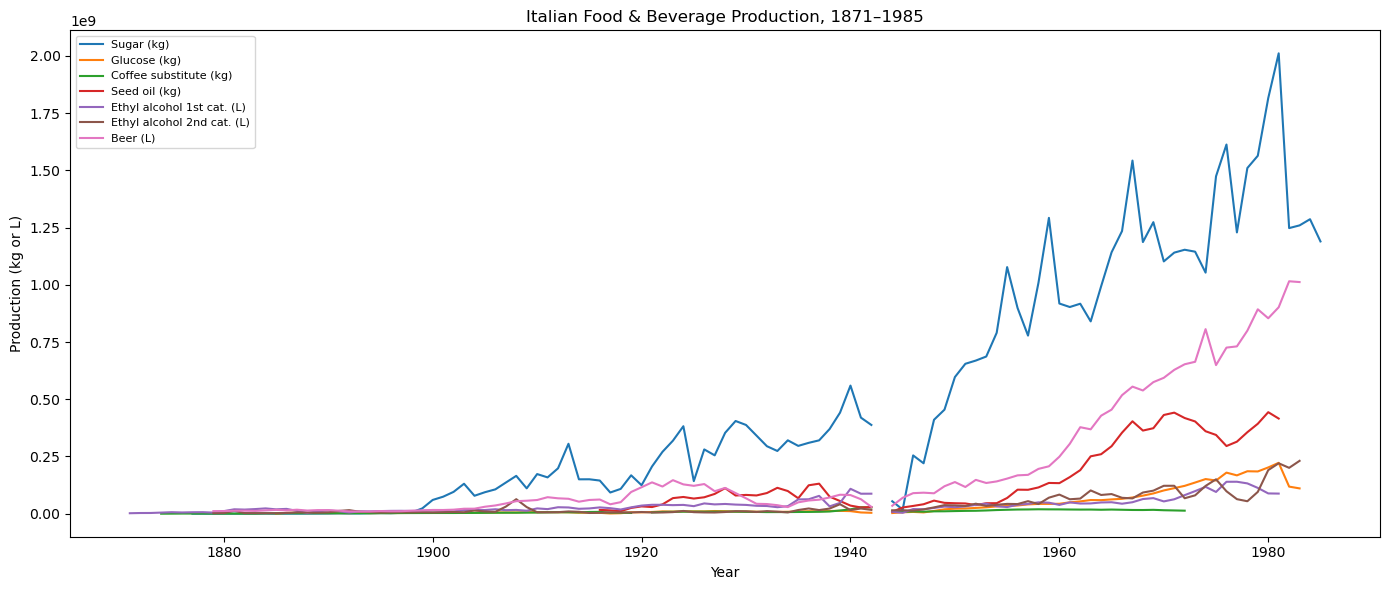

In [3]:
import matplotlib.pyplot as plt

cols = {
    'Sugar_kg':      'Sugar (kg)',
    'Glucose_kg':    'Glucose (kg)',
    'Coffee_sub_kg': 'Coffee substitute (kg)',
    'Seed_oil_kg':   'Seed oil (kg)',
    'Ethyl_alc1_L':  'Ethyl alcohol 1st cat. (L)',
    'Ethyl_alc2_L':  'Ethyl alcohol 2nd cat. (L)',
    'Beer_L':        'Beer (L)',
}

fig, ax = plt.subplots(figsize=(14, 6))

for col, label in cols.items():
    ax.plot(fb['Year'], fb[col], label=label, linewidth=1.5)

ax.legend(fontsize=8)
ax.set_xlabel('Year')
ax.set_ylabel('Production (kg or L)')
ax.set_title('Italian Food & Beverage Production, 1871–1985')
plt.tight_layout()
plt.show()

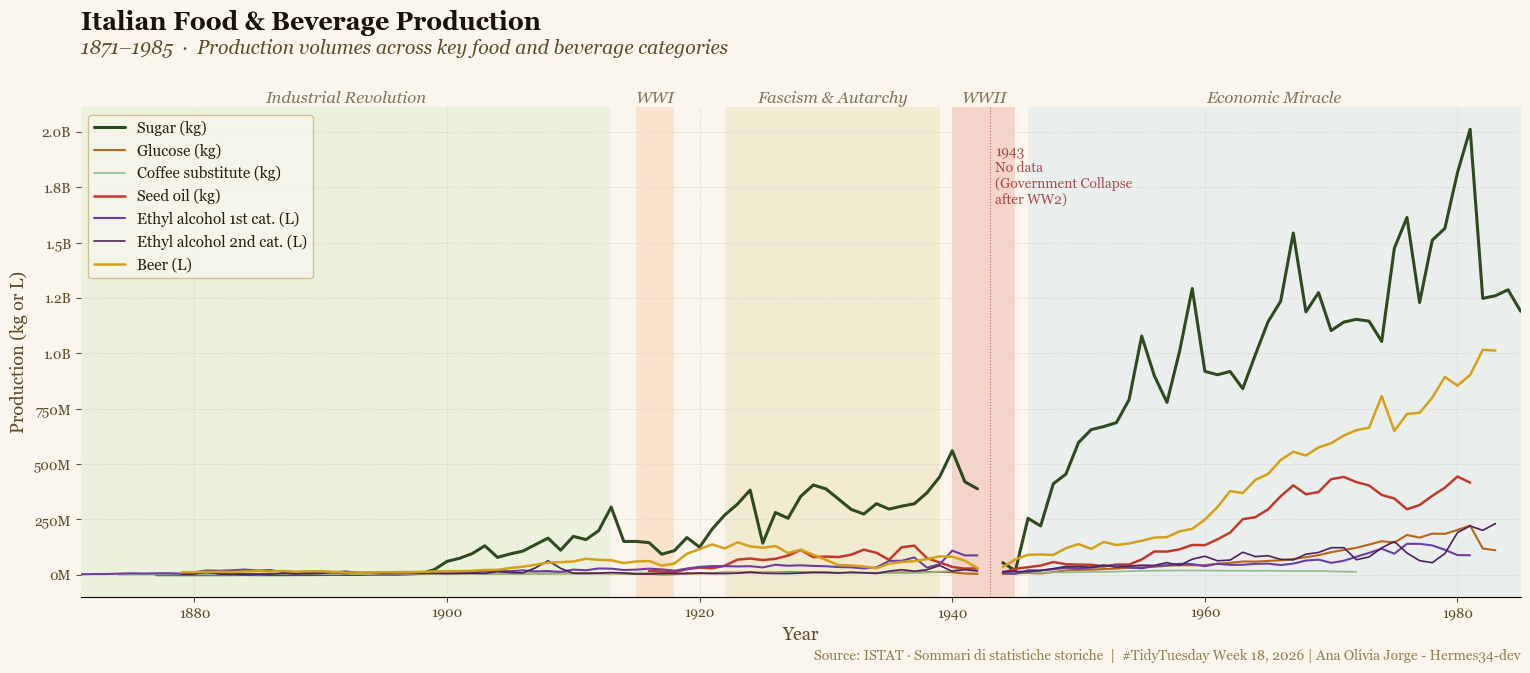

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
fb = pd.read_csv('food_beverages.csv')

fb['Sugar_kg']       = fb['Sugar'] * 1000
fb['Glucose_kg']     = fb['Glucose'] * 100
fb['Coffee_sub_kg']  = fb['Coffee_substitute'] * 100
fb['Seed_oil_kg']    = fb['Seed_oil'] * 100
fb['Ethyl_alc1_L']   = fb['Ethyl_alcohol_1'] * 100
fb['Ethyl_alc2_L']   = fb['Ethyl_alcohol_2'] * 100
fb['Beer_L']         = fb['Beer'] * 100

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Georgia', 'Palatino', 'DejaVu Serif'],
    'axes.facecolor':    '#faf6ee',
    'figure.facecolor':  '#faf6ee',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom':True,
    'axes.grid':         True,
    'grid.color':        '#e0d8c8',
    'grid.linewidth':    0.5,
    'grid.linestyle':    '--',
    'xtick.color':       '#5c4a28',
    'ytick.color':       '#5c4a28',
    'axes.labelcolor':   '#5c4a28',
    'text.color':        '#2a1f0e',
})

# ── Historical periods ────────────────────────────────────────────────────────
periods = [
    (1871, 1913, '#d4e8c2', 0.35, 'Industrial Revolution'),
    (1915, 1918, '#f5c6a0', 0.40, 'WWI'),
    (1922, 1939, '#e8d5a0', 0.35, 'Fascism & Autarchy'),
    (1940, 1945, '#f0a899', 0.42, 'WWII'),
    (1946, 1985, '#c8dff0', 0.30, 'Economic Miracle'),
]

# ── Line palette — warm editorial tones ───────────────────────────────────────
lines = [
    ('Sugar_kg',      '#2e4a1e', 2.2,  'Sugar (kg)'),
    ('Glucose_kg',    '#b5651d', 1.5,  'Glucose (kg)'),
    ('Coffee_sub_kg', '#8fbc8f', 1.2,  'Coffee substitute (kg)'),
    ('Seed_oil_kg',   '#c0392b', 1.8,  'Seed oil (kg)'),
    ('Ethyl_alc1_L',  '#6b3fa0', 1.5,  'Ethyl alcohol 1st cat. (L)'),
    ('Ethyl_alc2_L',  '#4a235a', 1.2,  'Ethyl alcohol 2nd cat. (L)'),
    ('Beer_L',        '#d4a017', 1.8,  'Beer (L)'),
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(1871, 1985)
fig.subplots_adjust(top=0.82, bottom=0.12, left=0.07, right=0.97)

# Period bands
for x0, x1, color, alpha, label in periods:
    ax.axvspan(x0, x1, color=color, alpha=alpha, zorder=0, linewidth=0)
    ax.text(
        (x0 + x1) / 2, ax.get_ylim()[1],
        label,
        ha='center', va='bottom',
        fontsize=12, color='#5c4a28',
        style='italic', alpha=0.75,
        transform=ax.get_xaxis_transform(),
    )

# Lines
for col, color, lw, label in lines:
    ax.plot(fb['Year'], fb[col], color=color, linewidth=lw,
            label=label, zorder=3, solid_capstyle='round')

# 1943 annotation
ax.axvline(1943, color='#8b1a1a', linewidth=0.8, linestyle=':', alpha=0.6, zorder=4)
ax.text(1943.4, ax.get_ylim()[1] * 0.92,
        '1943\nNo data \n(Government Collapse\nafter WW2)',
        fontsize=10, color='#8b1a1a', alpha=0.75,
        transform=ax.transData, va='top')

# ── Labels & legend ───────────────────────────────────────────────────────────
ax.set_xlabel('Year', fontsize=13, labelpad=4)
ax.set_ylabel('Production (kg or L)', fontsize=13, labelpad=4)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M')
)

ax.legend(
    loc='upper left', fontsize=11,
    framealpha=0.7, facecolor='#faf6ee',
    edgecolor='#c8a96e', frameon=True,
    labelcolor='#2a1f0e',
)

# ── Title block ───────────────────────────────────────────────────────────────
fig.text(0.07, 0.93,
         'Italian Food & Beverage Production',
         fontsize=18, fontweight='bold', color='#1a1209',
         fontfamily='serif')
fig.text(0.07, 0.895,
         '1871–1985  ·  Production volumes across key food and beverage categories',
         fontsize=14, color='#5c4a28', style='italic')
fig.text(0.97, 0.03,
         'Source: ISTAT · Sommari di statistiche storiche  |  #TidyTuesday Week 18, 2026 | Ana Olívia Jorge - Hermes34-dev',
         fontsize=10, color="#664d0f", ha='right', alpha=0.7)

#plt.savefig("Tidy_tuesday_Week 2.png", dpi = 300)
plt.show()